# Clustering Analysis of Telecommunications Company to find the Churn

In [64]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import joblib
import os
output_dir = r"C:\Users\61491\OneDrive\Desktop\Customer-churn-Analysis\Clustering_Analysis"

# Clustering Analysis Work Flow
1. Feature Selection
2. Scaling
3. Elbow Method
4. Silhouette Analysis
5. Train Final K-Means
6. Save Model
7. PCA 
8. Plot Clusters + Centroids

### loading Clean data set

In [71]:
df_clustering=pd.read_csv(r"C:\Users\61491\OneDrive\Desktop\Customer-churn-Analysis\Clustering_Analysis\X_cluster_scaled.csv")

In [72]:
print(df_clustering.head())
df_clustering.info()

   gender  SeniorCitizen  Dependents  tenure  PhoneService  MonthlyCharges  \
0       0              0           0       1             0              25   
1       1              0           0      41             1              25   
2       0              0           1      52             1              19   
3       0              0           0       1             1              76   
4       1              0           0      67             1              51   

   Churn  MultipleLines_Yes  InternetService_Fiber optic  Contract_One year  \
0      1                  0                            0                  0   
1      0                  0                            0                  1   
2      0                  0                            0                  0   
3      1                  0                            0                  1   
4      0                  0                            1                  0   

   Contract_Two year  
0                  0  
1         

checking Correlationship between features 

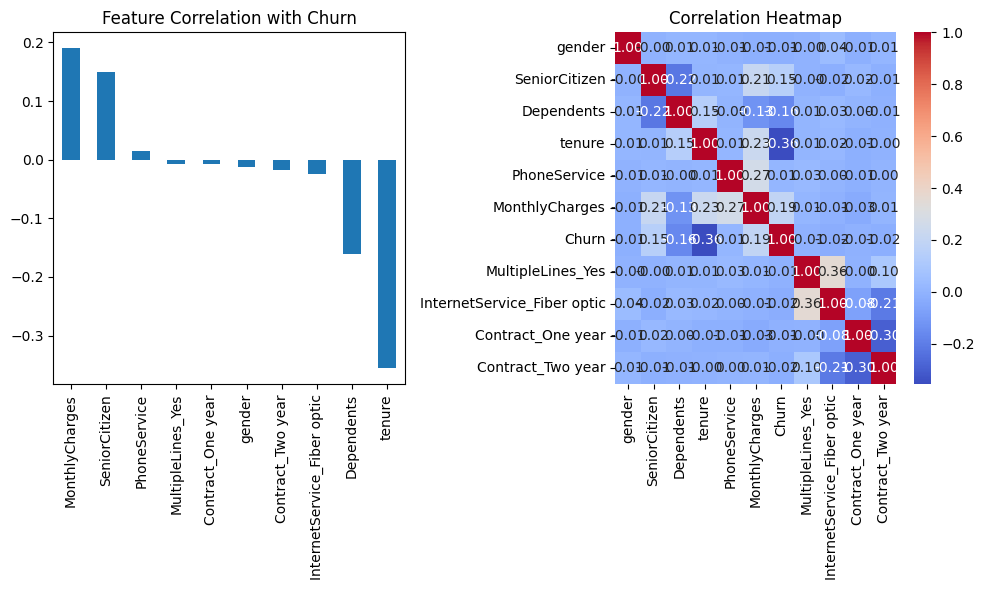

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(10, 6))
corr_matrix = df_clustering.corr(numeric_only=True)

churn_corr = corr_matrix["Churn"].sort_values(ascending=False)
churn_corr.drop("Churn").plot(kind="bar", ax=axes[0])
axes[0].set_title("Feature Correlation with Churn")

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", ax=axes[1])
axes[1].set_title("Correlation Heatmap")

plt.tight_layout()


plt.savefig(
    os.path.join(output_dir, "combined_correlation_page.png"),
    dpi=300,
    bbox_inches='tight'
)

plt.show()

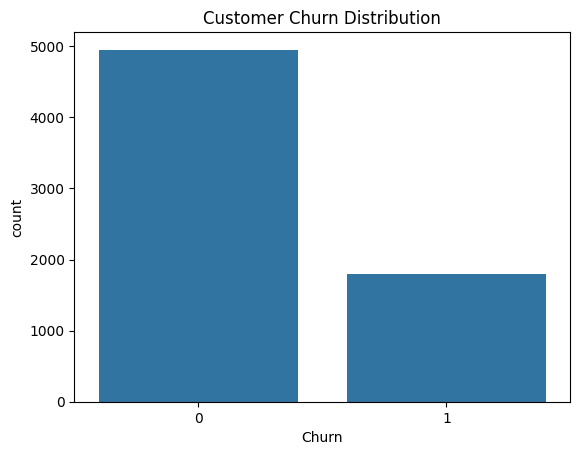

In [75]:
sns.countplot(x="Churn", data=df_clustering)
plt.title("Customer Churn Distribution")
plt.savefig(r"C:\Users\61491\OneDrive\Desktop\Customer-churn-Analysis\Clustering_Analysis\Visualization\1_churn_distribution", dpi=300, bbox_inches='tight')
plt.show()

# Feature selection for clustering
1. converted data types to int


In [76]:
X_cluster = df_clustering.drop(columns=["Churn"]).copy()
print(f"Shape of clustering dataset: {X_cluster.shape}")
# Check data types
print(X_cluster.dtypes)

Shape of clustering dataset: (6741, 10)
gender                         int64
SeniorCitizen                  int64
Dependents                     int64
tenure                         int64
PhoneService                   int64
MonthlyCharges                 int64
MultipleLines_Yes              int64
InternetService_Fiber optic    int64
Contract_One year              int64
Contract_Two year              int64
dtype: object


# Scaling data for the clustering analysis

In [78]:
scaler = StandardScaler()
X_cluster_scaled = pd.DataFrame(
    scaler.fit_transform(X_cluster),
    columns=X_cluster.columns,
    index=X_cluster.index
)
print(f"Scaled dataset shape: {X_cluster_scaled.shape}")
display(X_cluster_scaled.head())
X_cluster_scaled.to_csv(
    r"C:\Users\61491\OneDrive\Desktop\Customer-churn-Analysis\Clustering_Analysis\Clusterung_scaled_.csv",
    index=False
)
print("\nFeature Means:")
print(X_cluster_scaled.mean().round(2))
print("\nFeature Standard Deviations:")
print(X_cluster_scaled.std().round(2))
print("\nMissing values after scaling:")
print(X_cluster_scaled.isnull().sum())


Scaled dataset shape: (6741, 10)


,gender,SeniorCitizen,Dependents,tenure,PhoneService,MonthlyCharges,MultipleLines_Yes,InternetService_Fiber optic,Contract_One year,Contract_Two year
0,-1.006698,-0.448765,-0.661297,-1.312875,-3.002723,-1.376228,-0.854798,-0.886128,-0.520967,-0.569071
1,0.993347,-0.448765,-0.661297,0.331038,0.333031,-1.376228,-0.854798,-0.886128,1.919506,-0.569071
2,-1.006698,-0.448765,1.512180,0.783114,0.333031,-1.578399,-0.854798,-0.886128,-0.520967,-0.569071
3,-1.006698,-0.448765,-0.661297,-1.312875,0.333031,0.342225,-0.854798,-0.886128,1.919506,-0.569071
4,0.993347,-0.448765,-0.661297,1.399582,0.333031,-0.500154,-0.854798,1.128505,-0.520967,-0.569071



Feature Means:
gender                        -0.0
SeniorCitizen                 -0.0
Dependents                    -0.0
tenure                         0.0
PhoneService                   0.0
MonthlyCharges                -0.0
MultipleLines_Yes              0.0
InternetService_Fiber optic   -0.0
Contract_One year              0.0
Contract_Two year             -0.0
dtype: float64

Feature Standard Deviations:
gender                         1.0
SeniorCitizen                  1.0
Dependents                     1.0
tenure                         1.0
PhoneService                   1.0
MonthlyCharges                 1.0
MultipleLines_Yes              1.0
InternetService_Fiber optic    1.0
Contract_One year              1.0
Contract_Two year              1.0
dtype: float64

Missing values after scaling:
gender                         0
SeniorCitizen                  0
Dependents                     0
tenure                         0
PhoneService                   0
MonthlyCharges              

# Determine Optimal Number of Clusters (Elbow Method)

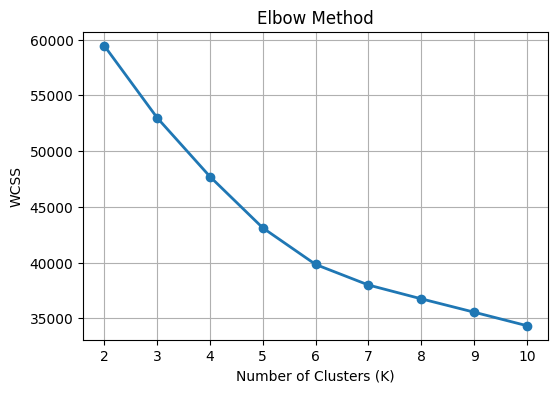

k = 2: WCSS = 59446.74
k = 3: WCSS = 52985.57
k = 4: WCSS = 47706.46
k = 5: WCSS = 43104.47
k = 6: WCSS = 39824.95
k = 7: WCSS = 37981.43
k = 8: WCSS = 36741.67
k = 9: WCSS = 35543.56
k = 10: WCSS = 34330.54


In [55]:
wcss = []
for i in range(2, 11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
        
    )
    kmeans.fit(X_cluster_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(
    range(2,11),
    wcss,
    marker="o",
    linewidth=2
       )
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.grid(True)
plt.savefig(
    r"C:\Users\61491\OneDrive\Desktop\Customer-churn-Analysis\Clustering_Analysis\elow_method.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
for k, inertia in zip(range(2,11), wcss):
    print(f"k = {k}: WCSS = {inertia:.2f}")

# Silhouette_score checking for number of cluster

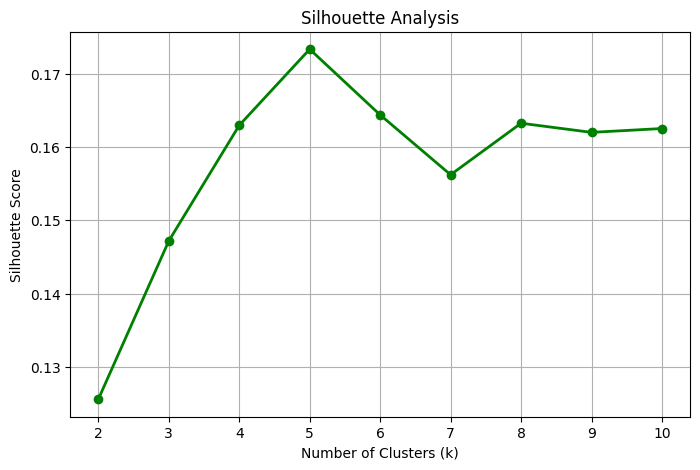

k = 2: Silhouette Score = 0.1256
k = 3: Silhouette Score = 0.1472
k = 4: Silhouette Score = 0.1630
k = 5: Silhouette Score = 0.1734
k = 6: Silhouette Score = 0.1644
k = 7: Silhouette Score = 0.1562
k = 8: Silhouette Score = 0.1633
k = 9: Silhouette Score = 0.1620
k = 10: Silhouette Score = 0.1625

Recommended number of clusters: 5
Highest Silhouette Score: 0.1734


In [50]:
from sklearn.metrics import silhouette_score
scores = []
for k in range(2, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = model.fit_predict(X_cluster_scaled)
    score = silhouette_score(
        X_cluster_scaled,
        labels
    )
    scores.append(score)
plt.figure(figsize=(8, 5))
plt.plot(
    range(2, 11),
    scores,
    marker="o",
    color="green",
    linewidth=2
)
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.grid(True)
plt.savefig(
    r"C:\Users\61491\OneDrive\Desktop\Customer-churn-Analysis\Clustering_Analysis\Silhoutte_analysis.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
for k, score in zip(range(2, 11), scores):
    print(f"k = {k}: Silhouette Score = {score:.4f}")
best_k = range(2, 11)[np.argmax(scores)]
best_score = max(scores)
print(f"\nRecommended number of clusters: {best_k}")
print(f"Highest Silhouette Score: {best_score:.4f}")

## Train K-Means Model


In [57]:

optimal_k = 3    

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_cluster_scaled)
print("First 10 Cluster Assignments:")
print(clusters[:10])

cluster_counts = pd.Series(clusters).value_counts().sort_index()
print("\\nCustomers in Each Cluster:")
print(cluster_counts)

joblib.dump(
    kmeans,
    os.path.join(output_dir, "kmeans_model.pkl")
)

# Save the scaler
joblib.dump(
    scaler,
    os.path.join(output_dir, "scaler.pkl")
)

print(f"\\nK-Means model with {optimal_k} clusters saved successfully.")
with open(os.path.join(output_dir, "train_kmeans.py"), "w") as f:
    f.write(code_snippet)

First 10 Cluster Assignments:
[0 2 2 2 1 1 1 2 1 2]
\nCustomers in Each Cluster:
0     673
1    2670
2    3398
Name: count, dtype: int64
\nK-Means model with 3 clusters saved successfully.


In [19]:
loaded_model = joblib.load(
    r"C:\Users\61491\OneDrive\Desktop\Customer-churn-Analysis\Clustering_Analysis\Trained K-Means Model\kmeans_model.pkl"
)

loaded_model.predict(X_cluster_scaled)

array([0, 2, 2, ..., 2, 1, 1])

## PCA Dimensionality Reduction

In [58]:
pca = PCA(
    n_components=2,
    random_state=42
)

X_pca = pca.fit_transform(X_cluster_scaled)

print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

print(f"\nTotal Explained Variance: {pca.explained_variance_ratio_.sum():.4f}")
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"],
    index=X_cluster_scaled.index
)

pca_df["Cluster"] = clusters

display(pca_df.head())

Explained Variance Ratio:
[0.14642298 0.13863249]

Total Explained Variance: 0.2851


,PC1,PC2,Cluster
0,-2.368897,-1.723890,0
1,-0.896489,-1.008481,2
2,-1.350592,-0.862840,2
3,-0.105270,-1.222504,2
4,0.045799,0.593922,1


## PCA Cluster Visualization

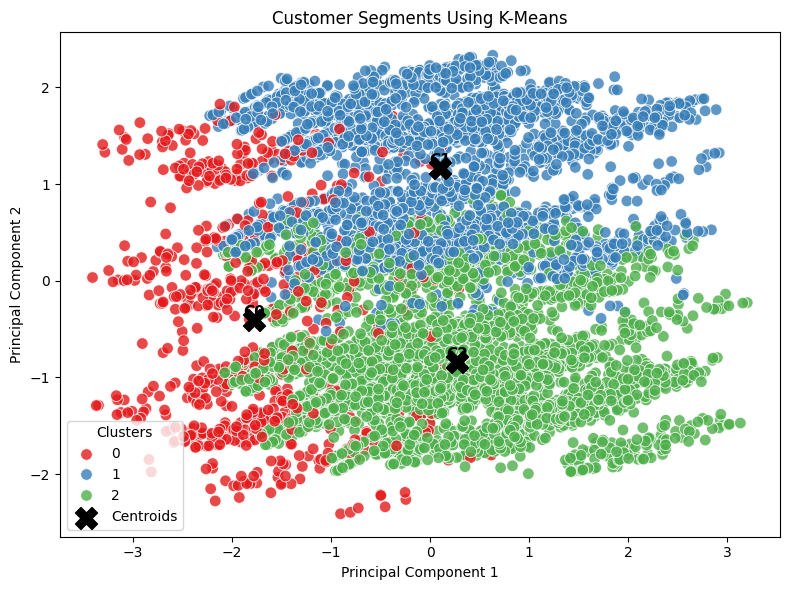

In [61]:
# Transform cluster centroids into PCA space
pca = PCA(n_components=2)
pca_components = pca.fit_transform(X_cluster_scaled.values)
centroids_pca = pca.transform(kmeans.cluster_centers_)

# PCA DataFrame
pca_df = pd.DataFrame(pca_components, columns=["PC1", "PC2"])
pca_df["Cluster"] = clusters
# Transform centroids
centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.figure(figsize=(8, 6))
# Scatter plot of customers
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set1",
    s=70,
    alpha=0.8
)# Plot centroids
plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    s=250,
    c="black",
    marker="X",
    label="Centroids"
)

# Label centroids
for i, (x, y) in enumerate(centroids_pca):
    plt.text(
        x, y,
        f"C{i}",
        fontsize=11,
        fontweight="bold",
        color="black",
        ha="center",
        va="bottom"
    )

plt.title("Customer Segments Using K-Means")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Clusters", loc="best", frameon=True)
plt.tight_layout()

plt.savefig(
    os.path.join(output_dir, "PCA_visualization.png"),
    
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Cluster Profile Analysis

In [60]:
# --- Cluster Summary ---
cluster_profile = (
    X_cluster_scaled
    .assign(Cluster=clusters)
    .groupby("Cluster")
    .mean(numeric_only=True)
    .round(2)
)

cluster_sizes = (
    pd.Series(clusters)
    .value_counts()
    .sort_index()
)

cluster_percent = (
    cluster_sizes / len(clusters) * 100
).round(2)

cluster_summary = cluster_profile.copy()
cluster_summary.insert(0, "Customers", cluster_sizes.values)
cluster_summary.insert(1, "Percentage (%)", cluster_percent.values)

print("========== Cluster Summary ==========")
display(cluster_summary)
cluster_summary.to_csv(
    os.path.join(output_dir, "cluster_summary.cvs"),
    index=True
)


========== Cluster Summary ==========


,Customers,Percentage (%),SeniorCitizen,tenure,MonthlyCharges,gender_Male,Dependents_Yes,PhoneService_Yes,MultipleLines_Yes,InternetService_Fiber optic,Contract_One year,Contract_Two year
Cluster,,,,,,,,,,,,
0,673,9.98,-0.04,-0.04,-0.80,0.02,0.00,-3.00,-0.08,-0.00,0.04,-0.00
1,2670,39.61,-0.01,0.03,0.08,0.04,0.03,0.33,0.42,1.13,-0.08,-0.24
2,3398,50.41,0.02,-0.02,0.10,-0.03,-0.03,0.33,-0.31,-0.89,0.06,0.19


In [62]:
# --- Cluster-wise Churn Rate ---
cluster_churn_rate = (
    df_clustering
    .assign(Cluster=clusters)
    .groupby("Cluster")["Churn_Yes"]
    .mean()
    .round(3)
)


cluster_churn_rate = cluster_churn_rate.to_frame("Churn Rate")

print("========== Cluster-wise Churn Rate ==========")
display(cluster_churn_rate)
cluster_churn_rate.to_csv(
    os.path.join(output_dir, "churn_rate.csv"),
    index=True
)

========== Cluster-wise Churn Rate ==========


,Churn Rate
Cluster,
0,0.247
1,0.257
2,0.276


In [56]:
# --- Churn-wise Cluster Distribution ---
churn_cluster_dist = (
    df_clustering
    .assign(Cluster=clusters)
    .groupby("Churn_Yes")["Cluster"]
    .value_counts(normalize=True)
    .rename("Percentage")
    .mul(100)
    .round(2)
    .to_frame()
    
)

print("========== Churn-wise Cluster Distribution ==========")
display(churn_cluster_dist)

========== Churn-wise Cluster Distribution ==========


Percentage
Churn_Yes Cluster            
False     2             49.68
          1             40.08
          0             10.24
True      2             52.43
          1             38.30
          0              9.27

## Cluster Characteristics Visualization

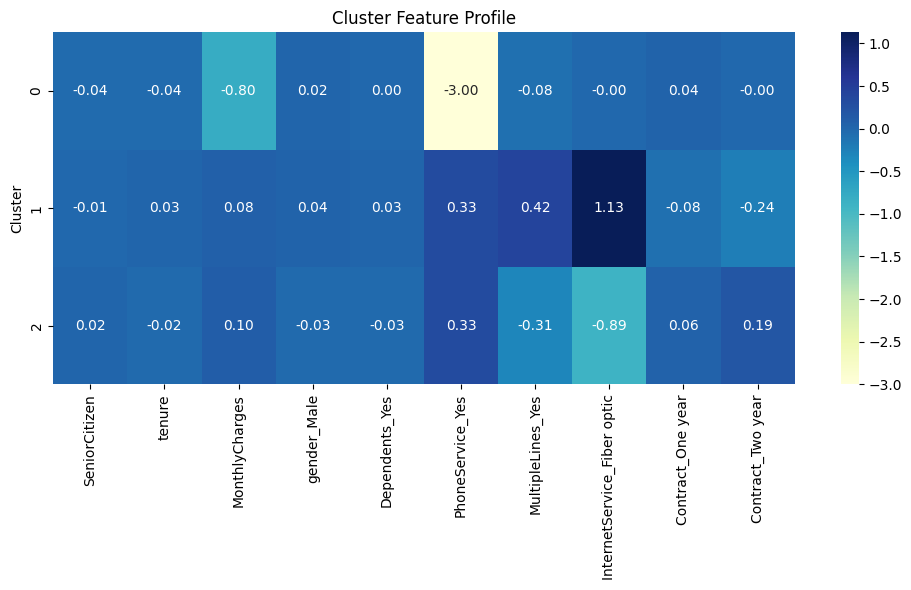

In [57]:
plt.figure(figsize=(10,6))

sns.heatmap(
    cluster_profile,
    annot=True,
    cmap="YlGnBu",
    
    fmt=".2f"
    
)


plt.title("Cluster Feature Profile")

plt.tight_layout()
plt.savefig( r"C:\Users\61491\OneDrive\Desktop\Customer-churn-Analysis\Clustering_Analysis\characteistic_visualization.png",
    dpi=300,
    bbox_inches="tight")
plt.show()